# Phase 3 · Notebook 1 — 01_EDA
Univariate + bivariate analysis of the **real joined view** (orders ⋈ restaurant ⋈ menu), loaded from PostgreSQL via SQLAlchemy — the same cleaned source of truth every notebook reads.

### Reporting rules (Phase 0 findings, unchanged)
- **R1** Headline money = `currency='INR'` (USD segment measured & excluded)
- **R2** Reference "today" = `MAX(order_datetime)` in the data
- **R3** NULL-FK rows kept in overall aggregates, drop out of restaurant rollups


## Setup

In [1]:
# ---- boilerplate: paths, DB engine (SQLAlchemy from .env), helper --------
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

ROOT = Path.cwd()
if not (ROOT / "python").is_dir() and (ROOT.parent / "python").is_dir():
    ROOT = ROOT.parent
OUT = ROOT / "python" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
load_dotenv(ROOT / ".env")

DB_URL = os.getenv("DATABASE_URL")
assert DB_URL, "DATABASE_URL missing - check .env in the repo root"
engine = create_engine(DB_URL)

def q(sql):
    """read_sql via text(): keeps parameters=None so literal '%' in ILIKE is safe."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("ROOT:", ROOT, "| OUT:", OUT, "| DB connected OK", sep="\n")


ROOT:
D:\Projects\bharatinsight
| OUT:
D:\Projects\bharatinsight\python\outputs
| DB connected OK


## Joined analytical view
One row per order, enriched with restaurant attributes (rating may be NULL — Phase 0 finding #5).

In [2]:
df = q("""
SELECT o.order_id, o.order_datetime, o.quantity, o.sales_amount, o.currency,
       o.user_id, o.restaurant_id,
       r.name AS restaurant, r.location, r.rating, r.cost_for_two, r.cuisine
FROM orders o
JOIN restaurant r ON r.restaurant_id = o.restaurant_id
WHERE o.currency = 'INR'
""")
print(df.shape); display(df.head(3))
print("NULL ratings: %d (%.1f%%) — documented Phase 0 finding, kept as NULL"
      % (df["rating"].isna().sum(), 100*df["rating"].isna().mean()))

(148662, 12)


,order_id,order_datetime,quantity,sales_amount,currency,user_id,restaurant_id,restaurant,location,rating,cost_for_two,cuisine
0,2,2018-05-08,3,-1.0,INR,77359,531342,Janta Sweet House,Abohar,4.4,200.0,"Sweets,Bakery"
1,3,2018-04-06,1,875.0,INR,5321,158203,theka coffee desi,Abohar,3.8,100.0,Beverages
2,5,2018-06-18,6,7176.0,INR,75378,543530,GRILL MASTERS,Abohar,NaN,250.0,"Italian-American,Fast Food"


NULL ratings: 87138 (58.6%) — documented Phase 0 finding, kept as NULL


## Univariate — rating, cost-for-two, orders-per-day distributions

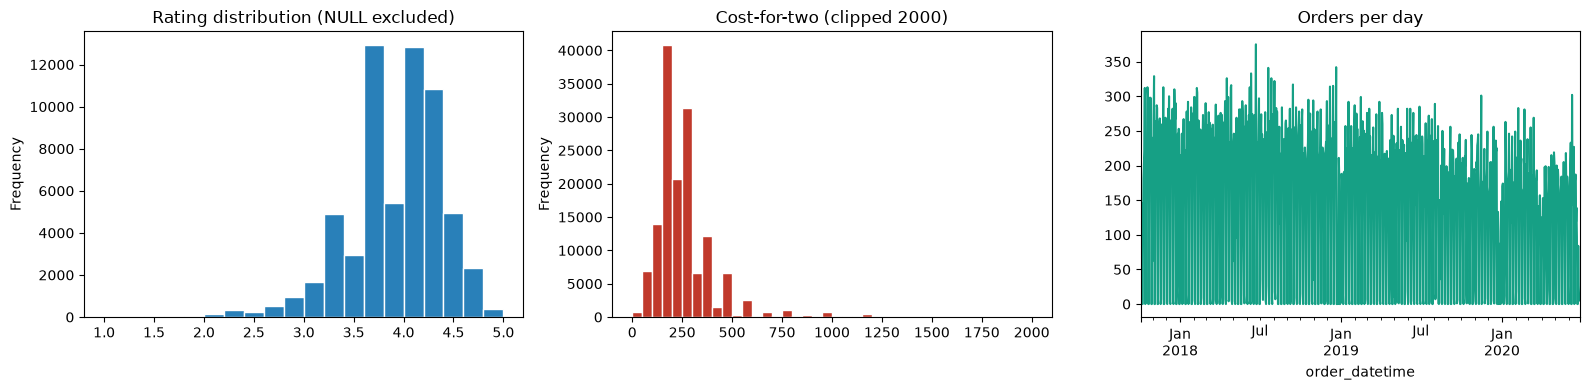

In [3]:
fig, (a1,a2,a3) = plt.subplots(1,3, figsize=(16,4))
df["rating"].dropna().plot.hist(bins=20, ax=a1, color="#2980b9", edgecolor="white")
a1.set_title("Rating distribution (NULL excluded)")
df["cost_for_two"].dropna().clip(0,2000).plot.hist(bins=40, ax=a2, color="#c0392b", edgecolor="white")
a2.set_title("Cost-for-two (clipped 2000)")
perday = df.set_index("order_datetime").resample("D")["order_id"].count()
perday.plot(ax=a3, color="#16a085"); a3.set_title("Orders per day")
fig.tight_layout(); fig.savefig(OUT/"eda_univariate.png", dpi=300); plt.show()

## Bivariate — cost vs rating scatter + location-level aggregate

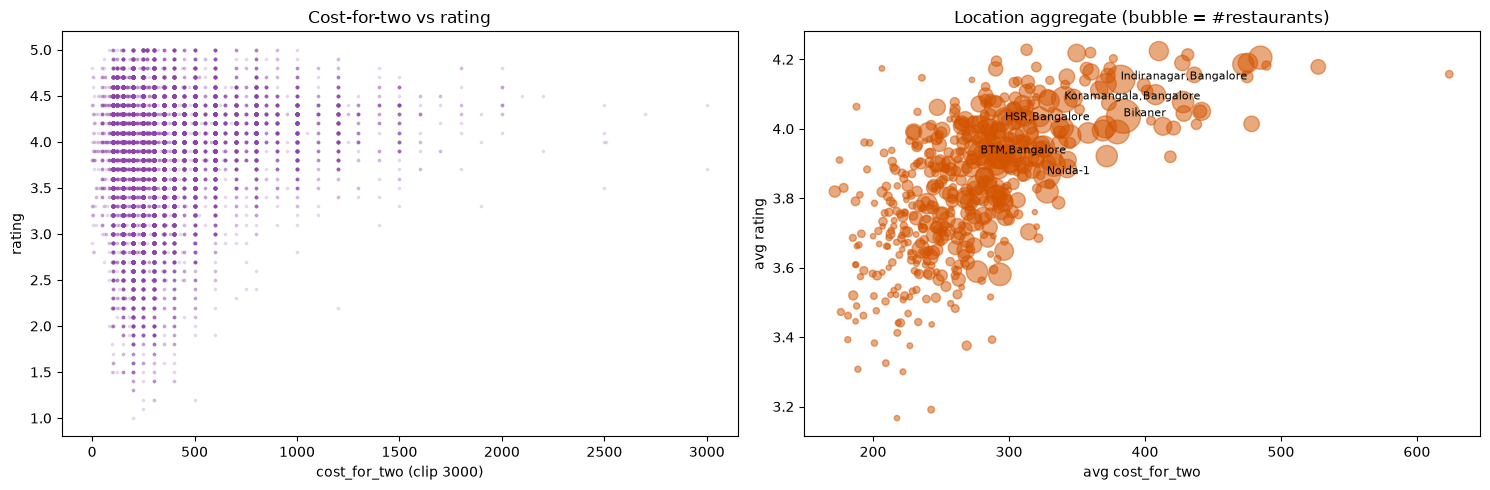

In [4]:
sam = df.dropna(subset=["rating","cost_for_two"])
fig, (a1,a2) = plt.subplots(1,2, figsize=(15,5))
a1.scatter(sam["cost_for_two"].clip(0,3000), sam["rating"], s=3, alpha=.15, color="#8e44ad")
a1.set_title("Cost-for-two vs rating"); a1.set_xlabel("cost_for_two (clip 3000)"); a1.set_ylabel("rating")
loc = (sam.groupby("location").agg(avg_cost=("cost_for_two","mean"),
                                   avg_rating=("rating","mean"),
                                   restaurants=("restaurant_id","nunique"))
          .query("restaurants>=20"))
a2.scatter(loc["avg_cost"], loc["avg_rating"], s=loc["restaurants"]/loc["restaurants"].max()*600,
           alpha=.5, color="#d35400")
for l,r in loc.nlargest(6,"restaurants").iterrows():
    a2.annotate(l, (r["avg_cost"], r["avg_rating"]), fontsize=8)
a2.set_title("Location aggregate (bubble = #restaurants)")
a2.set_xlabel("avg cost_for_two"); a2.set_ylabel("avg rating")
fig.tight_layout(); fig.savefig(OUT/"eda_bivariate.png", dpi=300); plt.show()

## Bivariate — cuisine vs average order value

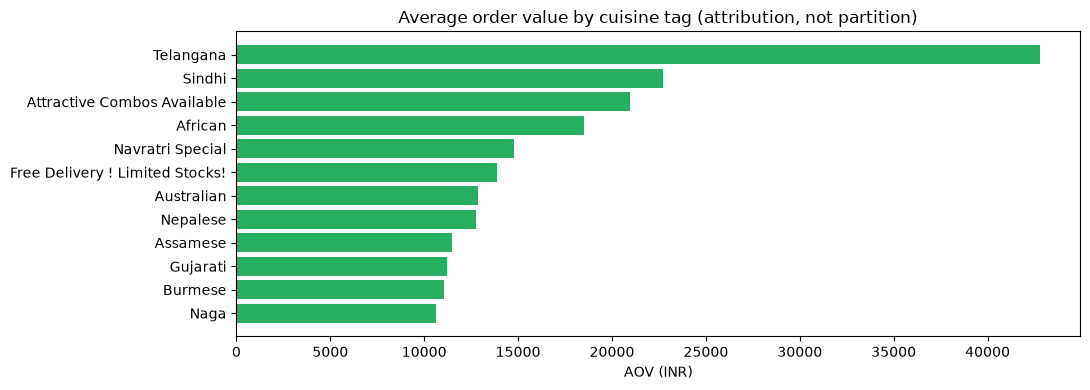

In [5]:
cui = q("""
SELECT trim(tag) AS cuisine_tag, ROUND(AVG(o.sales_amount),2) AS aov, COUNT(*) AS orders
FROM orders o JOIN restaurant r ON r.restaurant_id = o.restaurant_id,
     LATERAL unnest(string_to_array(r.cuisine, ',')) AS tag
WHERE o.currency='INR' AND r.cuisine IS NOT NULL
GROUP BY 1 ORDER BY aov DESC LIMIT 12
""")
fig, ax = plt.subplots(figsize=(11,4))
ax.barh(cui["cuisine_tag"][::-1], cui["aov"][::-1], color="#27ae60")
ax.set_title("Average order value by cuisine tag (attribution, not partition)")
ax.set_xlabel("AOV (INR)")
fig.tight_layout(); fig.savefig(OUT/"eda_cuisine_aov.png", dpi=300); plt.show()

## Correlation heatmap (numeric columns)

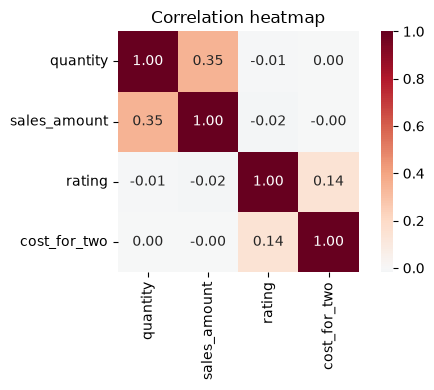


Reading: values near +1/-1 = strong linear relation; ~0 = no linear relation.


In [6]:
import seaborn as sns
num = df[["quantity","sales_amount","rating","cost_for_two"]].copy()
corr = num.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(5.5,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Correlation heatmap")
fig.tight_layout(); fig.savefig(OUT/"eda_correlation.png", dpi=300); plt.show()
print("\nReading: values near +1/-1 = strong linear relation; ~0 = no linear relation.")

## Findings (fill 3 observations here)
1. ...
2. ...
3. ...